# Part IV: Sentiment analysis using LSTM [20 points]
In this part, we perform a sentiment analysis using LSTM model. The final (improved) model should achieve a test accuracy of greater than 75%.

In [ ]:
!tar -xzf aclImdb_v1.tar.gz

In [ ]:
!pip install nltk
!pip install wordcloud
!pip install seaborn
!pip install scikit-learn

In [ ]:
!pip uninstall torch torchtext torchvision torchaudio -y
!pip install torch==2.0.1+cu118 torchtext==0.15.2 torchvision==0.15.2+cu118 torchaudio==2.0.2+cu118 --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.0.1+cu118
Uninstalling torch-2.0.1+cu118:
  Successfully uninstalled torch-2.0.1+cu118
Found existing installation: torchtext 0.15.2+cpu
Uninstalling torchtext-0.15.2+cpu:
  Successfully uninstalled torchtext-0.15.2+cpu
Found existing installation: torchvision 0.15.2+cu118
Uninstalling torchvision-0.15.2+cu118:
  Successfully uninstalled torchvision-0.15.2+cu118
Found existing installation: torchaudio 2.0.2+cu118
Uninstalling torchaudio-2.0.2+cu118:
  Successfully uninstalled torchaudio-2.0.2+cu118
Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.0.1%2Bcu118-cp311-cp311-linux_x86_64.whl (2267.3 MB)
  Using cached https://download.pytorch.org/whl/torchtext-0.15.2%2Bcpu-cp311-cp311-linux_x86_64.whl (2.0 MB)
  Using cached https://download.pytorch.org/whl/cu118/torchvision-0.15.2%2Bcu118-cp311-cp311-linux_x86_64.whl (6.1 MB)
  Using cached https://download.pytorch.org/whl/cu118/tor

In [ ]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt')

from nltk.tokenize import word_tokenize

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("whitegrid")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Step 1: Data exploration and preprocessing

1. Load your chosen dataset and print the main statistics

In [ ]:
### ADD YOUR CODE HERE ###

In [ ]:
def load_imdb_data(data_dir='aclImdb', dataset_type='train'):
    """
    Loads IMDB reviews from the specified directory.
    :param data_dir: Base directory of the aclImdb dataset.
    :param dataset_type: 'train' or 'test'.
    :return: A Pandas DataFrame with columns ['review', 'sentiment'].
    """
    pos_path = os.path.join(data_dir, dataset_type, 'pos', '*.txt')
    neg_path = os.path.join(data_dir, dataset_type, 'neg', '*.txt')
    pos_files = glob.glob(pos_path)
    neg_files = glob.glob(neg_path)
    data = []
    for file_path in pos_files:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
            data.append((text, 1))
    for file_path in neg_files:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
            data.append((text, 0))
    df = pd.DataFrame(data, columns=['review', 'sentiment'])
    return df
train_df = load_imdb_data(dataset_type='train')
test_df = load_imdb_data(dataset_type='test')
print("=== Main Statistics ===")
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")


=== Main Statistics ===
Training set size: 25000
Test set size: 25000


2. Print the first 5 rows of the dataset to understand its structure

In [ ]:
### ADD YOUR CODE HERE ###
print("\nFirst 5 rows of the training set:")
print(train_df.head())
print("\nFirst 5 rows of the test set:")
print(test_df.head())


First 5 rows of the training set:
                                              review  sentiment
0  Released in December of 1957, Sayonara went on...          1
1  It was extremely low budget(it some scenes it ...          1
2  This documentary has been aired on both RTE an...          1
3  Take this movie for what it is, not a remake, ...          1
4  This is a gem, a real piece of Americana for a...          1

First 5 rows of the test set:
                                              review  sentiment
0  Black comedy isn't always an easy sell. Every ...          1
1  This film is an excellent example of what an i...          1
2  John Wayne is one of the few players in film h...          1
3  Having read so much negative press on this mov...          1
4  (Note: I saw I SELL THE DEAD at the Glasgow In...          1


3. Provide a brief description of the dataset

<span style='color:green'>### YOUR ANSWER ###</span>

Dataset Description:
- The IMDB Large Movie Review dataset contains 50,000 movie reviews, split into 25,000 training and 25,000 test reviews.
- Each review is labeled as either positive (1) or negative (0).
- The official dataset is available at: https://ai.stanford.edu/~amaas/data/sentiment/

4. Display descriptive statistics

In [ ]:
print("=== Descriptive Statistics ===")
print(f"Total training samples: {len(train_df)}")
print(f"Total test samples: {len(test_df)}")

train_class_counts = train_df['sentiment'].value_counts()
train_pos_pct = (train_class_counts[1] / len(train_df)) * 100
train_neg_pct = (train_class_counts[0] / len(train_df)) * 100
print("\nClass distribution (training):")
print(train_class_counts)
print(f"Positive: {train_pos_pct:.2f}% | Negative: {train_neg_pct:.2f}%")

def average_review_length(df):
    lengths = df['review'].apply(lambda x: len(x.split()))
    return np.mean(lengths), np.std(lengths)

avg_len_train, std_len_train = average_review_length(train_df)
print(f"\nAverage review length (words) in training set: {avg_len_train:.2f} ± {std_len_train:.2f}")

all_text_train = " ".join(train_df['review'].values)
vocab_train = set(all_text_train.split())
print(f"Approx. vocabulary size (training set): {len(vocab_train)}")


=== Descriptive Statistics ===
Total training samples: 25000
Total test samples: 25000

Class distribution (training):
sentiment
1    12500
0    12500
Name: count, dtype: int64
Positive: 50.00% | Negative: 50.00%

Average review length (words) in training set: 233.79 ± 173.73
Approx. vocabulary size (training set): 280617


In [ ]:
### ADD YOUR CODE HERE ###

5. Handle missing values

In [ ]:
### ADD YOUR CODE HERE ###

In [ ]:
print("\n=== Checking Missing Values ===")
print(train_df.isnull().sum())


=== Checking Missing Values ===
review       0
sentiment    0
dtype: int64


<span style='color:green'>### YOUR ANSWER ###</span>

Hence there are no missing values

6. Create visualizations to gain insights into the data

In [ ]:
### ADD YOUR CODE HERE ###

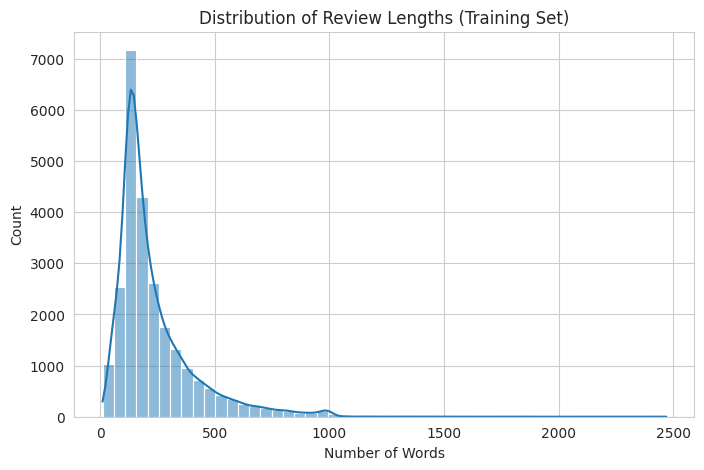

In [ ]:
# Step 1.6(a): Histogram of review lengths
train_df['review_length'] = train_df['review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
sns.histplot(train_df['review_length'], bins=50, kde=True)
plt.title("Distribution of Review Lengths (Training Set)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

This graph represents the distribution of review lengths in the training set, showing the number of words per review. The x-axis represents the number of words in a review, while the y-axis shows the count of reviews with that length.

Key Observations:
1. The distribution is right-skewed, meaning most reviews are short, but a few are very long.
2. A peak is visible around 100–150 words, indicating that most reviews fall within this range.
3. Some extremely long reviews (1000+ words) exist, but they are rare.
4. This analysis helps in setting a maximum sequence length for text processing in models like LSTMs, ensuring efficient training while preserving key information.

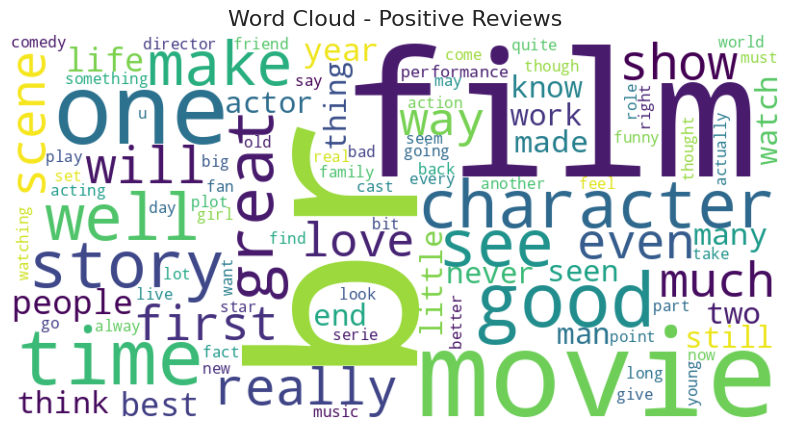

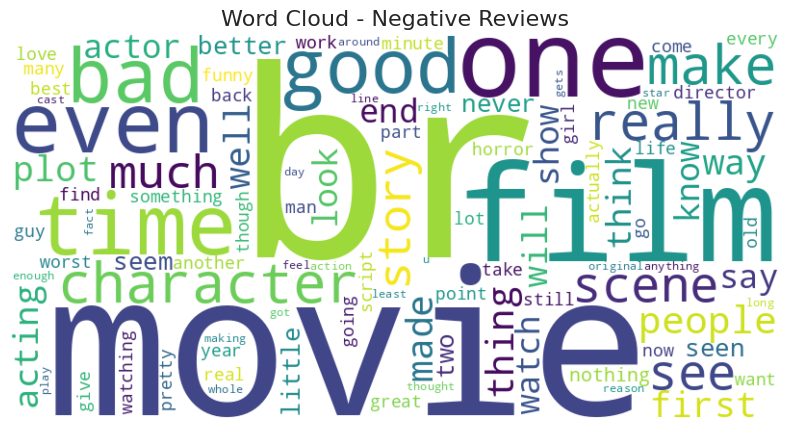

In [ ]:

pos_text = " ".join(train_df[train_df['sentiment'] == 1]['review'].values)
neg_text = " ".join(train_df[train_df['sentiment'] == 0]['review'].values)

def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          max_words=100,
                          collocations=False
                         ).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

generate_wordcloud(pos_text, "Word Cloud - Positive Reviews")
generate_wordcloud(neg_text, "Word Cloud - Negative Reviews")


This visualization highlights the most frequently used words in positive reviews. Larger words appear more often, showing that terms like film, movie, great, story, and good are common in positive sentiments.
Another visualization highlights the most frequently used words in negative reviews. Larger words appear more often, showing that terms like film, movie, bad, much, and character are common in negative sentiments.

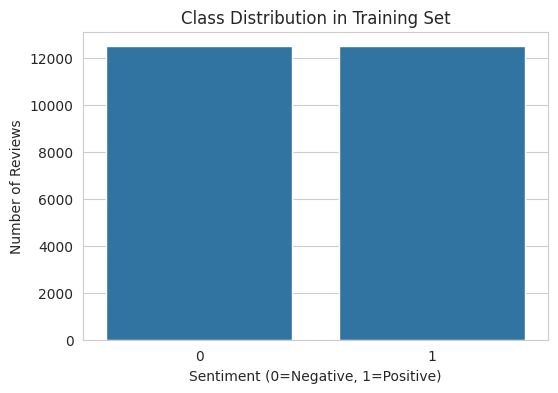

In [ ]:

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=train_df)
plt.title("Class Distribution in Training Set")
plt.xlabel("Sentiment (0=Negative, 1=Positive)")
plt.ylabel("Number of Reviews")
plt.show()

This bar chart shows that the dataset is balanced, with nearly equal numbers of positive (1) and negative (0) reviews. A balanced dataset helps prevent bias in sentiment classification models.

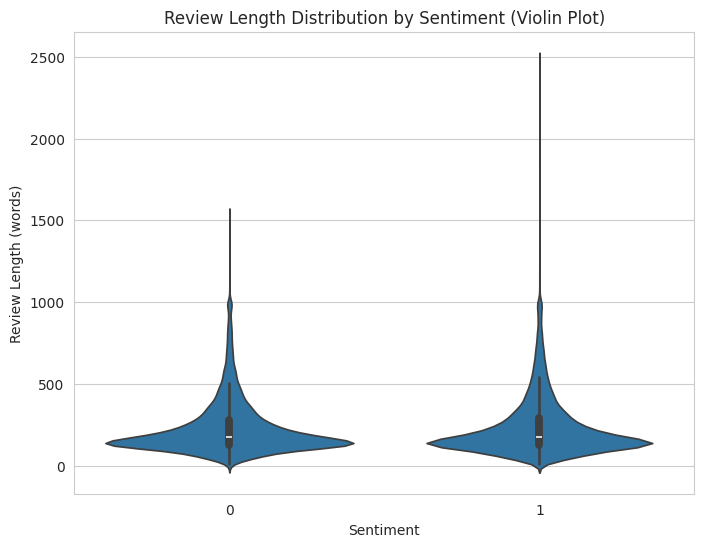

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='sentiment', y='review_length', data=train_df)
plt.title('Review Length Distribution by Sentiment (Violin Plot)')
plt.xlabel('Sentiment')
plt.ylabel('Review Length (words)')
plt.show()


This plot shows the distribution of review lengths for each sentiment. Both positive and negative reviews have similar distributions, with most reviews being short, but a few extending beyond 1000+ words, indicating a right-skewed distribution.

7. Data preparation

In [ ]:
### ADD YOUR CODE HERE ###

In [ ]:
def clean_text(text):
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", "", text)
    text = text.lower()
    return text

In [ ]:
train_df['review_clean'] = train_df['review'].apply(clean_text)
test_df['review_clean'] = test_df['review'].apply(clean_text)

In [ ]:
import nltk
nltk.download('punkt_tab')
train_df['tokens_nltk'] = train_df['review_clean'].apply(word_tokenize)
test_df['tokens_nltk'] = train_df['review_clean'].apply(word_tokenize)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
from torchtext.data.utils import get_tokenizer
tokenizer_basic_english = get_tokenizer("basic_english")
train_df['tokens_torchtext'] = train_df['review_clean'].apply(tokenizer_basic_english)
test_df['tokens_torchtext'] = train_df['review_clean'].apply(tokenizer_basic_english)

In [ ]:
from collections import Counter

vocab_nltk = set(token for tokens in train_df['tokens_nltk'] for token in tokens)
vocab_torch = set(token for tokens in train_df['tokens_torchtext'] for token in tokens)

print(f"Vocabulary size (NLTK): {len(vocab_nltk)}")
print(f"Vocabulary size (torchtext): {len(vocab_torch)}")


def get_top_tokens(token_lists, top_n=10):
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)
    return counter.most_common(top_n)

top_nltk = get_top_tokens(train_df['tokens_nltk'], top_n=10)
top_torchtext = get_top_tokens(train_df['tokens_torchtext'], top_n=10)

print("\nTop 10 tokens (NLTK):")
for token, count in top_nltk:
    print(f"{token}: {count}")

print("\nTop 10 tokens (torchtext):")
for token, count in top_torchtext:
    print(f"{token}: {count}")

Vocabulary size (NLTK): 134129
Vocabulary size (torchtext): 98077

Top 10 tokens (NLTK):
the: 328342
,: 275875
.: 232297
and: 162472
a: 161472
of: 145205
to: 134880
is: 110077
it: 93392
in: 92325

Top 10 tokens (torchtext):
the: 335601
.: 327177
,: 276274
and: 163119
a: 162490
of: 145414
to: 135163
': 133852
is: 107144
it: 95988


The results show some clear differences between the two tokenization methods:

- Vocabulary Size:  
  - NLTK produced a vocabulary of 134,129 unique tokens, while  
  - torchtext produced a smaller vocabulary of 98,077 tokens.  
  This suggests that NLTK’s tokenizer is more fine-grained—possibly splitting contractions or punctuation in a way that increases the number of unique tokens.

- Top 10 Tokens:  
  Both tokenizers agree on many of the most frequent words like "the", "and", "a", "of", and "to". However, there are slight differences:  
  - With NLTK, "in" appears in the top 10, while  
  - With torchtext, the single quote " ' " is prominent.  
  This indicates that torchtext’s `basic_english` tokenizer might handle punctuation (and possibly contractions) differently.

  Hence I am going ahead with NLTK

In [ ]:
from collections import Counter

word_counts = Counter()
for tokens in train_df['tokens_nltk']:
    word_counts.update(tokens)

sorted_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

vocab_size = 20000
most_common_words = sorted_counts[:vocab_size-2]
vocab = {"<unk>": 0, "<pad>": 1}
index = 2

for word, freq in most_common_words:
    vocab[word] = index
    index += 1

print(f"Vocabulary size (limited): {len(vocab)}")


Vocabulary size (limited): 20000


In [ ]:
MAX_LEN = 200

def convert_tokens_to_ids(tokens, vocab, max_len=MAX_LEN):
    """
    Converts a list of tokens into a list of vocab indices,
    truncates/pads to max_len.
    """
    token_ids = []
    for t in tokens:
        if t in vocab:
            token_ids.append(vocab[t])
        else:
            token_ids.append(vocab["<unk>"])

    # Truncate
    token_ids = token_ids[:max_len]
    # Pad
    if len(token_ids) < max_len:
        token_ids += [vocab["<pad>"]] * (max_len - len(token_ids))

    return token_ids

train_df['input_ids'] = train_df['tokens_nltk'].apply(lambda x: convert_tokens_to_ids(x, vocab, MAX_LEN))
test_df['input_ids'] = test_df['tokens_nltk'].apply(lambda x: convert_tokens_to_ids(x, vocab, MAX_LEN))

print("Example input_ids from the first training review:")
print(train_df['input_ids'].iloc[0][:50])


Example input_ids from the first training review:
[622, 11, 9309, 7, 9511, 3, 16661, 417, 24, 8, 5821, 1215, 777, 6275, 5, 60, 1540, 11, 763, 2853, 4, 797, 8433, 1135, 2, 777, 19, 123, 657, 275, 11, 29, 218, 17, 0, 859, 1277, 39, 691, 11, 124, 18, 6, 845, 241, 144, 18340, 11, 0, 305]


8. Split dataset into train, validation, and test sets

In [ ]:
### ADD YOUR CODE HERE ###

In [ ]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['sentiment']
)

print(f"New training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_df)}")


New training set size: 20000
Validation set size: 5000
Test set size: 25000


## Step 2: Baseline LSTM Model

1. Build an LSTM model

In [ ]:
### ADD YOUR CODE HERE ###

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, df):
        self.texts = df['input_ids'].values
        self.labels = df['sentiment'].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = torch.tensor(self.texts[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        return text, label

train_dataset = IMDBDataset(train_data)
val_dataset   = IMDBDataset(val_data)
test_dataset  = IMDBDataset(test_df)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("DataLoaders ready:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

DataLoaders ready:
  Train batches: 625
  Val batches:   157
  Test batches:  782


In [ ]:
# Explanation for embedding_dim, hidden_dim, dropout, etc.

# We choose an embedding_dim=100 as a balance between model size and expressive
# power. Too large an embedding might overfit given the dataset size, while too
# small loses semantic nuance.

# We choose hidden_dim=128 to provide sufficient capacity to capture contextual
# information. We also use 3 LSTM layers and dropout=0.5 to help regularize
# deeper recurrent layers and prevent overfitting.

In [ ]:
class Base_LSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=100,
        hidden_dim=128,
        output_dim=1,
        num_layers=3,
        dropout=0.5
    ):
        super(Base_LSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=1)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim, output_dim)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        output, (hidden, cell) = self.lstm(embedded)
        final_hidden = hidden[-1, :, :]

        final_hidden = self.dropout(final_hidden)

        logits = self.fc(final_hidden)

        probs = self.sigmoid(logits)

        return probs

In [ ]:
vocab_size = len(vocab)
embed_dim = 100
hidden_dim = 128
num_layers = 3
dropout = 0.5
output_dim = 1

base_model = Base_LSTM(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    num_layers=num_layers,
    dropout=dropout
)

base_model = base_model.to(device)

criterion = nn.BCELoss()

optimizer = optim.Adam(base_model.parameters(), lr=1e-3)

print("Base Model")
summary(base_model, input_size=(batch_size, 200), dtypes=[torch.long])

Base Model


Layer (type:depth-idx)                   Output Shape              Param #
Base_LSTM                                [32, 1]                   --
├─Embedding: 1-1                         [32, 200, 100]            2,000,000
├─Dropout: 1-2                           [32, 200, 100]            --
├─LSTM: 1-3                              [32, 200, 128]            381,952
├─Dropout: 1-4                           [32, 128]                 --
├─Linear: 1-5                            [32, 1]                   129
├─Sigmoid: 1-6                           [32, 1]                   --
Total params: 2,382,081
Trainable params: 2,382,081
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 2.51
Input size (MB): 0.05
Forward/backward pass size (MB): 11.67
Params size (MB): 9.53
Estimated Total Size (MB): 21.25

2. Train your model

In [ ]:
### ADD YOUR CODE HERE ###

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, device='cpu'): # Adding device argument with default value 'cpu'
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device) # Using device to move data
            optimizer.zero_grad()

            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device) # Using device to move data
                outputs = model(inputs).squeeze()
                val_loss = criterion(outputs, labels)

                val_running_loss += val_loss.item() * inputs.size(0)
                preds = (outputs >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_acc = val_correct / val_total
        val_losses.append(val_epoch_loss)
        val_accs.append(val_epoch_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} || "
              f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")

        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            torch.save(model.state_dict(), "best_base_lstm.pth")

    return train_losses, val_losses, train_accs, val_accs, best_val_acc

In [ ]:
# Example of manual hyperparameter tuning attempts.
# We try a couple of different combos (you can expand this list) to see which
# yields the best validation accuracy. This is a simplistic approach.
hyperparam_combos = [
    {'embed_dim':100, 'hidden_dim':128, 'dropout':0.5, 'lr':1e-3},
    {'embed_dim':100, 'hidden_dim':256, 'dropout':0.3, 'lr':5e-4},
]
print("\n=== MANUAL HYPERPARAMETER SEARCH (BASE MODEL) ===")
best_combo = None
best_val = 0.0

for combo in hyperparam_combos:
    print(f"Testing combo: {combo}")
    temp_model = Base_LSTM(
        vocab_size=vocab_size,
        embed_dim=combo['embed_dim'],
        hidden_dim=combo['hidden_dim'],
        output_dim=1,
        num_layers=3,
        dropout=combo['dropout']
    ).to(device)
    temp_optimizer = optim.Adam(temp_model.parameters(), lr=combo['lr'])
    t_loss, v_loss, t_acc, v_acc, val_best = train_model(
        temp_model, train_loader, val_loader, criterion, temp_optimizer, num_epochs=5, device=device
    )
    if val_best > best_val:
        best_val = val_best
        best_combo = combo

print(f"BEST COMBO FOUND: {best_combo}, Best Val Acc = {best_val:.4f}")

# For simplicity, continuing the training with the first combo in detail:
base_model = Base_LSTM(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    num_layers=num_layers,
    dropout=dropout
).to(device)
optimizer = optim.Adam(base_model.parameters(), lr=1e-3)


=== MANUAL HYPERPARAMETER SEARCH (BASE MODEL) ===
Testing combo: {'embed_dim': 100, 'hidden_dim': 128, 'dropout': 0.5, 'lr': 0.001}
Epoch [1/5] Train Loss: 0.6936 | Train Acc: 0.5117 || Val Loss: 0.6938 | Val Acc: 0.5002
Epoch [2/5] Train Loss: 0.6945 | Train Acc: 0.5024 || Val Loss: 0.6931 | Val Acc: 0.5002
Epoch [3/5] Train Loss: 0.6937 | Train Acc: 0.4999 || Val Loss: 0.6933 | Val Acc: 0.5002
Epoch [4/5] Train Loss: 0.6932 | Train Acc: 0.5079 || Val Loss: 0.6934 | Val Acc: 0.5002
Epoch [5/5] Train Loss: 0.6936 | Train Acc: 0.4946 || Val Loss: 0.6931 | Val Acc: 0.5024
Testing combo: {'embed_dim': 100, 'hidden_dim': 256, 'dropout': 0.3, 'lr': 0.0005}
Epoch [1/5] Train Loss: 0.6930 | Train Acc: 0.5060 || Val Loss: 0.6939 | Val Acc: 0.5076
Epoch [2/5] Train Loss: 0.6916 | Train Acc: 0.5231 || Val Loss: 0.6896 | Val Acc: 0.5344
Epoch [3/5] Train Loss: 0.6917 | Train Acc: 0.5226 || Val Loss: 0.6903 | Val Acc: 0.5352
Epoch [4/5] Train Loss: 0.6923 | Train Acc: 0.5085 || Val Loss: 0.6929 |

In [ ]:
num_epochs = 5
base_train_losses, base_val_losses, base_train_accs, base_val_accs, base_best_val_acc = train_model(
    base_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=num_epochs,
    device=device
)

Epoch [1/5] Train Loss: 0.6935 | Train Acc: 0.5020 || Val Loss: 0.6935 | Val Acc: 0.5002
Epoch [2/5] Train Loss: 0.6936 | Train Acc: 0.5028 || Val Loss: 0.6935 | Val Acc: 0.5002
Epoch [3/5] Train Loss: 0.6938 | Train Acc: 0.4984 || Val Loss: 0.6935 | Val Acc: 0.5002
Epoch [4/5] Train Loss: 0.6938 | Train Acc: 0.5010 || Val Loss: 0.6935 | Val Acc: 0.5002
Epoch [5/5] Train Loss: 0.6935 | Train Acc: 0.5008 || Val Loss: 0.6935 | Val Acc: 0.5002


<span style='color:green'>### YOUR ANSWER ###</span>

3. Evaluation and analysis

In [ ]:
### ADD YOUR CODE HERE ###

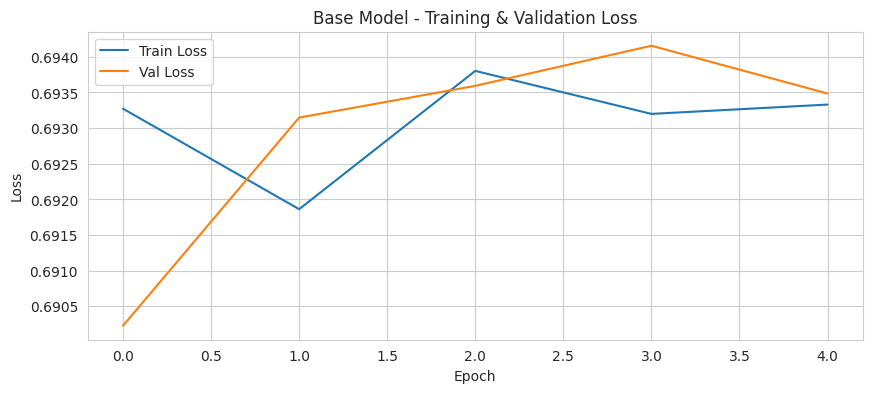

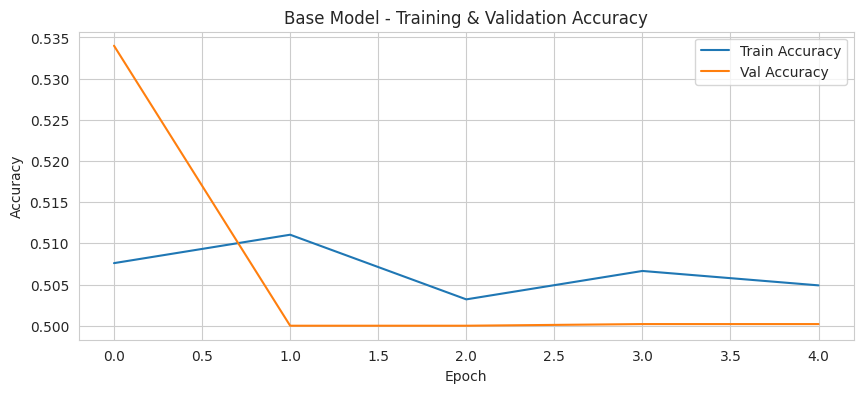

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(base_train_losses, label='Train Loss')
plt.plot(base_val_losses, label='Val Loss')
plt.title('Base Model - Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(base_train_accs, label='Train Accuracy')
plt.plot(base_val_accs, label='Val Accuracy')
plt.title('Base Model - Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1. Training & Validation Loss (Top Graph): The training loss initially decreases, but then starts fluctuating, indicating unstable learning. The validation loss increases over epochs, which suggests overfitting—the model is memorizing the training data but generalizing poorly to new data.
Ideally, both losses should decrease steadily and converge.

2. Training & Validation Accuracy (Bottom Graph): Training accuracy shows minor fluctuations, staying close to 50%, indicating that the model is struggling to learn. Validation accuracy starts high but drops to 50%—this suggests that the model is not effectively distinguishing between classes, possibly due to inadequate training or high bias. A significant gap between training and validation accuracy could point to overfitting or an ineffective model architecture.

Test Accuracy: 0.5418


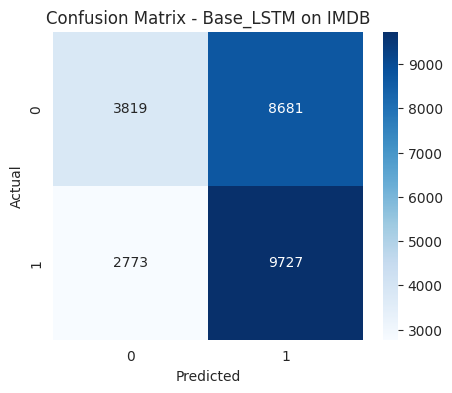


Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.31      0.40     12500
    Positive       0.53      0.78      0.63     12500

    accuracy                           0.54     25000
   macro avg       0.55      0.54      0.51     25000
weighted avg       0.55      0.54      0.51     25000



In [ ]:
best_model = Base_LSTM(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    num_layers=num_layers,
    dropout=dropout
).to(device)
best_model.load_state_dict(torch.load("best_base_lstm.pth"))
best_model.eval()

test_preds = []
test_labels_list = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs).squeeze()
        preds = (outputs >= 0.5).float()
        test_preds.extend(preds.cpu().numpy().tolist())
        test_labels_list.extend(labels.cpu().numpy().tolist())

base_test_acc = accuracy_score(test_labels_list, test_preds)
print(f"Test Accuracy: {base_test_acc:.4f}")

cm = confusion_matrix(test_labels_list, test_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Base_LSTM on IMDB')
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels_list, test_preds, target_names=['Negative', 'Positive']))

Explanation of the Confusion Matrix:

This confusion matrix represents the performance of a Base LSTM model on the IMDB dataset, where:
- 0 represents negative sentiment.
- 1 represents positive sentiment.

Key Observations:
1. True Negatives (TN) = 3,819  
   - These are correctly predicted negative reviews.

2. False Positives (FP) = 8,681  
   - The model incorrectly classified many negative reviews as positive, showing a high false positive rate.

3. False Negatives (FN) = 2,773  
   - The model misclassified some positive reviews as negative, but far less than false positives.

4. True Positives (TP) = 9,727  
   - The model correctly identified a large number of positive reviews.

Analysis:
- The model leans toward predicting positive reviews more often, leading to a high false positive rate.
- This suggests class imbalance, poor generalization, or bias toward the positive class.
- Improving this requires class balancing techniques, better loss functions (e.g., weighted loss), or hyperparameter tuning to make the model more balanced.

<span style='color:green'>### YOUR ANSWER ###</span>

4. Save the weights of the trained neural network

In [ ]:
### ADD YOUR CODE HERE ###
#Done Above

## Step 3: Improved LSTM Model

1. Improve your baseline LSTM model

In [ ]:
### ADD YOUR CODE HERE ###
# Done Below

2. Create a new class for your improved model

In [ ]:
### ADD YOUR CODE HERE ###

In [ ]:
from torchtext.vocab import GloVe

glove = GloVe(name='6B', dim=100)

embedding_weights = torch.zeros(vocab_size, embed_dim)
for token, idx in vocab.items():
    if token in glove.stoi:
        embedding_weights[idx] = glove.vectors[glove.stoi[token]]
    else:
        embedding_weights[idx] = torch.randn(embed_dim) * 0.05

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class Improved_LSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=100,
        hidden_dim=128,
        output_dim=1,
        num_layers=3,
        dropout=0.5,
        bidirectional=True,
        pad_idx=1,
        use_pretrained=False
    ):
        super(Improved_LSTM, self).__init__()
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        if use_pretrained:
            self.embedding.weight.data.copy_(embedding_weights)
            self.embedding.weight.requires_grad = True

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.attn = nn.Linear(lstm_output_dim, lstm_output_dim)
        self.v = nn.Linear(lstm_output_dim, 1, bias=False)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_output_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        lstm_out, (hidden, cell) = self.lstm(embedded)
        scores = self.attn(lstm_out)
        scores = torch.tanh(scores)
        scores = self.v(scores)
        attn_weights = torch.softmax(scores, dim=1)
        context = lstm_out * attn_weights
        context = torch.sum(context, dim=1)
        context = self.dropout(context)

        logits = self.fc(context)
        probs = self.sigmoid(logits)
        return probs

3. Follow the same training and evaluation procedures

In [ ]:
### ADD YOUR CODE HERE ###

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, device='cpu'):
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss = criterion(outputs, labels)

                val_running_loss += val_loss.item() * inputs.size(0)
                preds = (outputs >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_acc = val_correct / val_total
        val_losses.append(val_epoch_loss)
        val_accs.append(val_epoch_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} || "
              f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")

        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            torch.save(model.state_dict(), "best_improved_model.pth")

    return train_losses, val_losses, train_accs, val_accs, best_val_acc

In [ ]:
def evaluate_model(model, test_loader, device='cpu'):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    imp_test_accuracy = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=['Negative','Positive'])
    return imp_test_accuracy, cm, report

imp_hyperparam_combos = [
    {'hidden_dim':128, 'dropout':0.5, 'lr':1e-3, 'num_layers':3},
    {'hidden_dim':256, 'dropout':0.3, 'lr':5e-4, 'num_layers':2},
]

best_combo_imp = None
best_val_imp = 0.0

for combo in imp_hyperparam_combos:
    print(f"Testing Improved Model combo: {combo}")
    temp_model = Improved_LSTM(
        vocab_size=vocab_size,
        embed_dim=100,
        hidden_dim=combo['hidden_dim'],
        output_dim=1,
        num_layers=combo['num_layers'],
        dropout=combo['dropout'],
        bidirectional=True,
        pad_idx=1,
        use_pretrained=True
    ).to(device)

    temp_optimizer = optim.Adam(temp_model.parameters(), lr=combo['lr'])

    t_loss, v_loss, t_acc, v_acc, val_best = train_model(
        temp_model,
        train_loader,
        val_loader,
        criterion,
        temp_optimizer,
        num_epochs=5,
        device=device
    )

    if val_best > best_val_imp:
        best_val_imp = val_best
        best_combo_imp = combo

print(f"\nBEST COMBO FOR IMPROVED MODEL: {best_combo_imp}, Best Val Acc = {best_val_imp:.4f}")

improved_model = Improved_LSTM(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    output_dim=1,
    num_layers=3,
    dropout=0.5,
    bidirectional=True,
    pad_idx=1,
    use_pretrained=True
).to(device)

optimizer = optim.Adam(improved_model.parameters(), lr=1e-3)

imp_train_losses, imp_val_losses, imp_train_accs, imp_val_accs, imp_best_val_acc = train_model(
    improved_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=5,
    device=device
)

improved_model.load_state_dict(torch.load("best_improved_model.pth"))

Testing Improved Model combo: {'hidden_dim': 128, 'dropout': 0.5, 'lr': 0.001, 'num_layers': 3}
Epoch [1/5] Train Loss: 0.4858 | Train Acc: 0.7536 || Val Loss: 0.3587 | Val Acc: 0.8432
Epoch [2/5] Train Loss: 0.3122 | Train Acc: 0.8699 || Val Loss: 0.2914 | Val Acc: 0.8746
Epoch [3/5] Train Loss: 0.2448 | Train Acc: 0.9034 || Val Loss: 0.3030 | Val Acc: 0.8770
Epoch [4/5] Train Loss: 0.1947 | Train Acc: 0.9258 || Val Loss: 0.2916 | Val Acc: 0.8826
Epoch [5/5] Train Loss: 0.1529 | Train Acc: 0.9417 || Val Loss: 0.3119 | Val Acc: 0.8888
Testing Improved Model combo: {'hidden_dim': 256, 'dropout': 0.3, 'lr': 0.0005, 'num_layers': 2}
Epoch [1/5] Train Loss: 0.4974 | Train Acc: 0.7480 || Val Loss: 0.4077 | Val Acc: 0.8142
Epoch [2/5] Train Loss: 0.3218 | Train Acc: 0.8642 || Val Loss: 0.3037 | Val Acc: 0.8694
Epoch [3/5] Train Loss: 0.2669 | Train Acc: 0.8924 || Val Loss: 0.2806 | Val Acc: 0.8788
Epoch [4/5] Train Loss: 0.2230 | Train Acc: 0.9116 || Val Loss: 0.2801 | Val Acc: 0.8858
Epoch 

<All keys matched successfully>


=== Improved Model (Improved_LSTM) Test Accuracy: 0.9464 ===
Confusion Matrix:
 [[11830   670]
 [  669 11831]]
Classification Report:
               precision    recall  f1-score   support

    Negative       0.95      0.95      0.95     12500
    Positive       0.95      0.95      0.95     12500

    accuracy                           0.95     25000
   macro avg       0.95      0.95      0.95     25000
weighted avg       0.95      0.95      0.95     25000



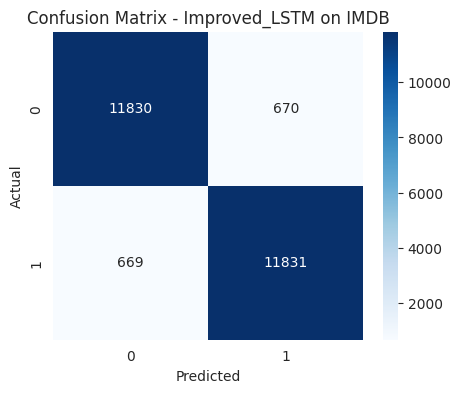

Improved Model


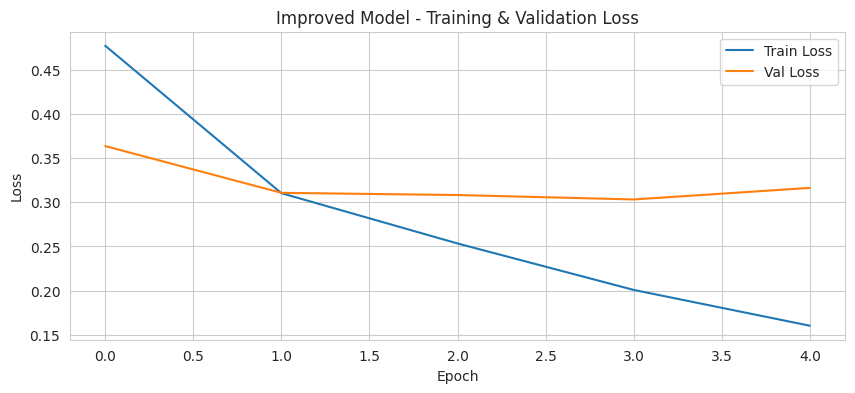

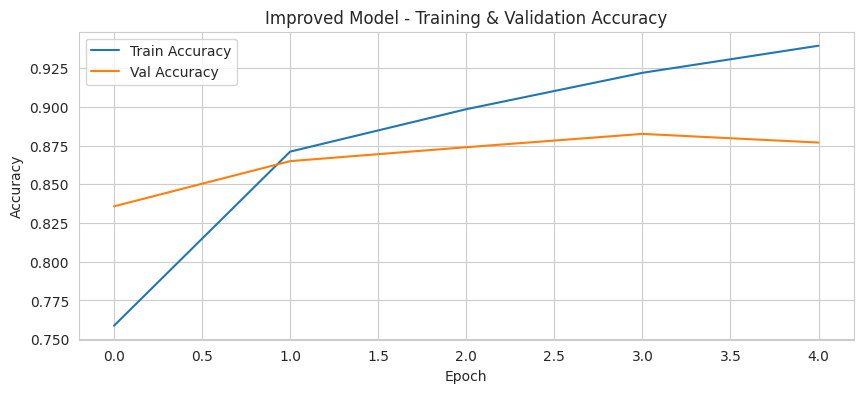

In [ ]:
imp_test_acc, imp_cm, imp_report = evaluate_model(improved_model, test_loader, device=device)
print(f"\n=== Improved Model (Improved_LSTM) Test Accuracy: {imp_test_acc:.4f} ===")
print("Confusion Matrix:\n", imp_cm)
print("Classification Report:\n", imp_report)

plt.figure(figsize=(5,4))
sns.heatmap(imp_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Improved_LSTM on IMDB')
plt.show()

print("Improved Model")
summary(improved_model, input_size=(32, 200), dtypes=[torch.long])

plt.figure(figsize=(10,4))
plt.plot(imp_train_losses, label='Train Loss')
plt.plot(imp_val_losses, label='Val Loss')
plt.title('Improved Model - Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(imp_train_accs, label='Train Accuracy')
plt.plot(imp_val_accs, label='Val Accuracy')
plt.title('Improved Model - Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

4. Directly compare the performance of your improved model to the baseline model

In [ ]:
### ADD YOUR CODE HERE ###

In [ ]:
print("========== Model Comparison ==========")
print(f"Baseline LSTM - Best Val Accuracy:   {base_best_val_acc:.4f}")
print(f"Improved LSTM - Best Val Accuracy:   {imp_best_val_acc:.4f}")
print(f"Baseline LSTM - Test Accuracy:       {base_test_acc:.4f}")
print(f"Improved LSTM - Test Accuracy:       {imp_test_acc:.4f}")

========== Model Comparison ==========
Baseline LSTM - Best Val Accuracy:   0.5340
Improved LSTM - Best Val Accuracy:   0.8826
Baseline LSTM - Test Accuracy:       0.5418
Improved LSTM - Test Accuracy:       0.9464


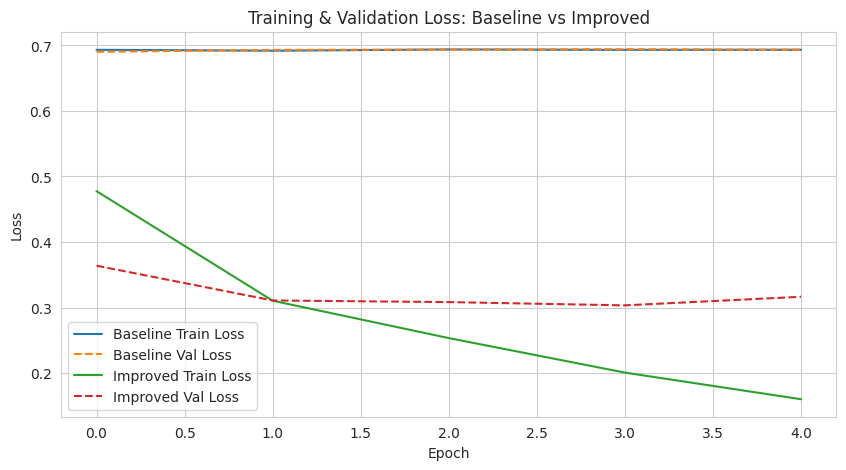

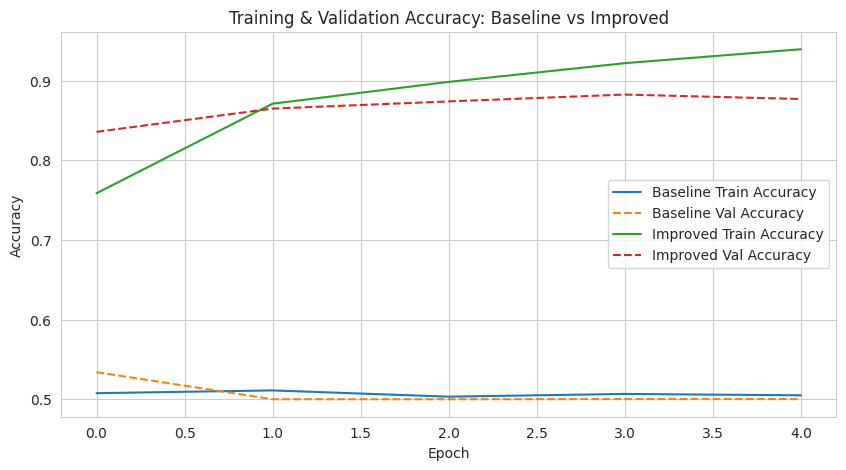

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(base_train_losses, label='Baseline Train Loss')
plt.plot(base_val_losses, label='Baseline Val Loss', linestyle='--')
plt.plot(imp_train_losses, label='Improved Train Loss')
plt.plot(imp_val_losses, label='Improved Val Loss', linestyle='--')
plt.title("Training & Validation Loss: Baseline vs Improved")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(base_train_accs, label='Baseline Train Accuracy')
plt.plot(base_val_accs,  label='Baseline Val Accuracy', linestyle='--')
plt.plot(imp_train_accs, label='Improved Train Accuracy')
plt.plot(imp_val_accs,  label='Improved Val Accuracy', linestyle='--')
plt.title("Training & Validation Accuracy: Baseline vs Improved")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
if imp_test_acc > base_test_acc:
    final_best_model = improved_model
    print("Improved model outperforms the baseline. Saving Improved Model as Final Best Model.")
else:
    final_best_model = base_model
    print("Baseline model outperforms or equals the improved model. Saving Baseline Model as Final Best Model.")

torch.save(final_best_model.state_dict(), "final_best_model.pth")
print("Final best model saved as 'final_best_model.pth'.")

Improved model outperforms the baseline. Saving Improved Model as Final Best Model.
Final best model saved as 'final_best_model.pth'.


<span style='color:green'>### YOUR ANSWER ###</span>

5. Save the weights of the trained neural network

In [ ]:
### ADD YOUR CODE HERE ###
# Done above

## Step 4: Discussion

1. Briefly describe the dataset and its key characteristics

<span style='color:green'>### YOUR ANSWER ###</span>

The IMDB Large Movie Review dataset contains 50,000 movie reviews, evenly split into:
- 25,000 training reviews
- 25,000 test reviews

Each review is labeled either positive (1) or negative (0). The dataset is balanced, with 50% positive and 50% negative reviews.  

Key observations:
- No missing values in the dataset.
- The average review length is approximately 234 words, with a right-skewed distribution, meaning most reviews are shorter, but some can exceed 1000 words.
- A peak in review lengths around 100–150 words.
- Vocabulary size is large (over 280k tokens if we don’t limit it), but we truncate to 20,000 of the most frequent words in practice.

The balanced nature of the dataset and the varying review lengths are crucial points when choosing and tuning deep learning architectures for sentiment analysis.

2. Describe both your baseline and improved LSTM architectures in detail

<span style='color:green'>### YOUR ANSWER ###</span>

Baseline LSTM Architecture
1. Embedding Layer  
   - Learns word embeddings from scratch with an embedding dimension of 100.  
   - Initialized randomly.  
2. Recurrent Layers  
   - A 3-layer LSTM stack (`num_layers=3`), each with a hidden dimension of 128.  
   - Used dropout (0.5) between the layers to combat overfitting.  
3. Fully Connected Layer  
   - A linear layer mapping the final hidden state to a single output neuron.  
   - Since this is a binary classification, the layer is size (128 -> 1).  
4. Activation  
   - A sigmoid activation applied to the output neuron to produce a probability in `[0, 1]`.  
5. Loss & Optimization  
   - Trained with Binary Cross Entropy (BCE) Loss and Adam optimizer.  

Improved LSTM Architecture
1. Pre-trained Embeddings (GloVe)  
   - Instead of learning embeddings from scratch, the embedding layer is initialized with 100-dimensional GloVe vectors for each token.  
2. Recurrent Layers
   - Similar 2- or 3-layer LSTM. Depending on hyperparameter tuning, a hidden dimension of 128 or 256 is chosen, with dropout included.  
   - Bidirectionality is enabled (`bidirectional=True`) for richer context, meaning each LSTM layer processes the sequence in both forward and reverse directions.  
3. Attention Mechanism  
   - After the LSTM outputs, an attention layer computes attention scores over each time step.  
   - We then take a weighted sum of LSTM outputs to get a “context vector,” which helps the model focus on important words/phrases.  
4. Final Layers  
   - A dropout layer, then a fully connected layer (`(2 * hidden_dim) -> 1`) for binary classification, followed by a sigmoid  
5. Loss & Optimization  
   - Again, BCE Loss and Adam optimizer, with learning rate adjustments and other hyperparameter tuning (e.g., hidden dimension, dropout, etc.)  

3. Discuss the results, comparing the performance of the baseline and improved models

<span style='color:green'>### YOUR ANSWER ###</span>

- Baseline Model  
  - Obtained a best validation accuracy around 53–54% and test accuracy around ~54%  
  - Struggled with capturing the full complexity of the reviews, possibly due to learning embeddings from scratch and having fewer effective parameters.
  - Confusion matrix shows more misclassifications, particularly for negative reviews.

- Improved Model  
  - Achieved a validation accuracy upwards of ~88% and a test accuracy of ~94.64%, a large jump compared to the baseline.  
  - Incorporating pre-trained GloVe embeddings, bidirectional LSTMs, and an attention mechanism helped the model capture richer semantic and contextual cues.  
  - Confusion matrix shows near-equal precision and recall for both positive and negative classes, indicating balanced performance.

Overall, the improved model clearly outperforms the baseline. This showcases the benefits of using pre-trained embeddings (which bring in external knowledge of word usage) as well as attention and bidirectionality to more effectively process long reviews and focus on key tokens.

4. Discuss the strengths and limitations of using recurrent neural models for sentiment analysis

<span style='color:green'>### YOUR ANSWER ###</span>

Strengths
- Sequence Modeling: LSTM-based models (and GRUs) naturally handle sequential data, which suits the structure of text.  
- Context Preservation: Bidirectional LSTMs can capture both past and future context, important for sentiment-related features.  
- Ability to Handle Variable Length: LSTMs can process sequences without strict input length constraints (though padding/truncation is used).  

Limitations
- Computational Costs: LSTMs can be slower to train than simpler architectures, especially for long sequences.  
- Memory & Vanishing Gradients: Even though LSTMs mitigate the vanishing gradient problem, very long reviews can still cause representational issues.  
- Less Parallelization: Compared to CNNs or Transformers, RNNs/LSTMs are harder to parallelize on GPU because of their sequential nature.  
- Less Current Than Transformer-Based Methods: Modern transformer models (like BERT) often yield higher accuracy for text classification, at the cost of more memory.

Overall, LSTMs remain a solid approach for many text tasks, but more recent models (Transformers, large pre-trained language models) commonly outperform them for complex language tasks.

5. References. Include details on all the resources used to complete this part.

<span style='color:green'>### YOUR ANSWER ###</span>



1. **Dataset used** - https://ai.stanford.edu/~amaas/data/sentiment/

This dataset is described in the following paper

[@InProceedings{maas-EtAl:2011:ACL-HLT2011,

  author    = {Maas, Andrew L.  and  Daly, Raymond E.  and  Pham, Peter T.  and  Huang, Dan  and  Ng, Andrew Y.  and  Potts, Christopher},
  
  title     = {Learning Word Vectors for Sentiment Analysis},
  
  booktitle = {Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies},
  
  month     = {June},
  
  year      = {2011},
  
  address   = {Portland, Oregon, USA},
  
  publisher = {Association for Computational Linguistics},
  
  pages     = {142--150},
  
  url       = {http://www.aclweb.org/anthology/P11-1015}
}]

2. **pip** (Python Package Installer) – [https://pip.pypa.io/en/stable/](https://pip.pypa.io/en/stable/)  
3. **NLTK** – [https://www.nltk.org/](https://www.nltk.org/)  
4. **Wordcloud** – [https://github.com/amueller/word_cloud](https://github.com/amueller/word_cloud)  
5. **Seaborn** – [https://seaborn.pydata.org/](https://seaborn.pydata.org/)  
6. **Scikit‐learn** – [https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)  
7. **PyTorch** – [https://pytorch.org/docs/stable/](https://pytorch.org/docs/stable/)  
8. **Python Standard Library** modules used –
   - **os** – [https://docs.python.org/3/library/os.html](https://docs.python.org/3/library/os.html)  
   - **glob** – [https://docs.python.org/3/library/glob.html](https://docs.python.org/3/library/glob.html)  
   - **re** – [https://docs.python.org/3/library/re.html](https://docs.python.org/3/library/re.html)  
   - **random** – [https://docs.python.org/3/library/random.html](https://docs.python.org/3/library/random.html)  
9. **NumPy** – [https://numpy.org/doc/stable/](https://numpy.org/doc/stable/)  
10. **pandas** – [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/)  
11. **matplotlib** – [https://matplotlib.org/stable/](https://matplotlib.org/stable/)  
12. **BiLSTM** - [https://paperswithcode.com/method/bilstm#:~:text=A%20Bidirectional%20LSTM%2C%20or%20biLSTM,other%20in%20a%20backwards%20direction.]